In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Assignment 7

## a) 
Ved et lineært liningssystem angiv belysningen af alle felter som funktion af afstanden fra hver lygtepæl, og deres felternes afstand til dem. Belysningen til hvert kvadrat fra et lygtepæl, er givet ved formlen: $y_j = x_i/d_{ij}^2$.

Dertil opstil koefficient matricen i python.

Ligningssystemet vil se således ud, hvor x som givet er lysstyrkerne fra hver enkelt lygtepæl, og hvor y er lysstyrken på hvert felt:

$\begin{bmatrix}
    \frac{1}{d_{0,0}^2} & \frac{1}{d_{1,0}^2} & \frac{1}{d_{2,0}^2} & \dots & \frac{1}{d_{11,0}^2} \\
    \frac{1}{d_{0,1}^2} & \frac{1}{d_{1,1}^2} & \frac{1}{d_{2,1}^2} & \dots & \frac{1}{d_{11,1}^2} \\
    \frac{1}{d_{0,2}^2} & \frac{1}{d_{1,2}^2} & \frac{1}{d_{2,2}^2} & \dots & \frac{1}{d_{11,2}^2} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    \frac{1}{d_{0,599}^2} & \frac{1}{d_{1,599}^2} & \frac{1}{d_{2,599}^2} & \dots & \frac{1}{d_{11,599}^2} \\
\end{bmatrix}
\begin{bmatrix}
    x_0 \\
    x_1 \\
    x_2 \\
    \vdots \\
    x_{11} \\
\end{bmatrix} =
\begin{bmatrix}
    y_0 \\
    y_1 \\
    y_2 \\
    \vdots \\
    y_{599} \\
\end{bmatrix}$

In [5]:
# Opstilling af koefficientmatricen i Python
# Først angiver jeg koordinaterne, for hver lygtepæl i en 3x12 matrice:
# 1. række = x, 2. række = y, 3. række = z.

P = np.array([[2, 4, 4, 11, 12, 13, 15, 16, 20, 23, 25, 28],
              [3, 13, 19, 5, 12, 18, 2, 16, 4, 12, 16, 9],
              [3.0, 3.6, 3.0, 3.5, 4.0, 3.6, 4.5, 3.0, 2.8, 4.0, 3.8, 3.4]])
P

array([[ 2. ,  4. ,  4. , 11. , 12. , 13. , 15. , 16. , 20. , 23. , 25. ,
        28. ],
       [ 3. , 13. , 19. ,  5. , 12. , 18. ,  2. , 16. ,  4. , 12. , 16. ,
         9. ],
       [ 3. ,  3.6,  3. ,  3.5,  4. ,  3.6,  4.5,  3. ,  2.8,  4. ,  3.8,
         3.4]])

In [6]:
# Opstilling af A

A = np.ones((600, 12))
i = 0
for y in range(20):
    for x in range(30):
        tile = np.array([[x + 0.5], 
                         [y + 0.5 ], 
                         [0]])
        # Beregner afstanden fra feltet til alle lamper og indsætter 1/distancen^2 i matricen.
        A[i, :] = 1 / np.linalg.norm(P - tile, axis=0) **2
        i += 1
 
# Felt nummer 0 vil være feltet nederst til højre, nr 1 er den lige over, nr 2 er den over den.
# Altså fylder jeg søjlerne op en for en nedefra og op.

A.round(4), A.shape
        

(array([[0.0571, 0.0055, 0.0028, ..., 0.0015, 0.0012, 0.0012],
        [0.0645, 0.0057, 0.0028, ..., 0.0016, 0.0012, 0.0013],
        [0.0645, 0.0058, 0.0028, ..., 0.0018, 0.0013, 0.0014],
        ...,
        [0.0011, 0.0016, 0.0018, ..., 0.0108, 0.0304, 0.0082],
        [0.001 , 0.0015, 0.0016, ..., 0.0098, 0.0257, 0.0082],
        [0.001 , 0.0014, 0.0015, ..., 0.0087, 0.0213, 0.0081]]),
 (600, 12))

## b)
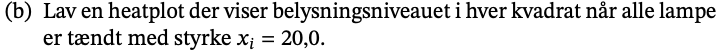

In [7]:
# Angivelse af lysstyrkerne (20 for alle).
x = (np.ones((12, 1)) * 20.0)

# Bestemmelse af lysniveauet af alle felter.
y = A @ x

C:\Users\Bruger\AppData\Local\Temp\ipykernel_11460\446730524.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  belysning[row][col] = y[i]


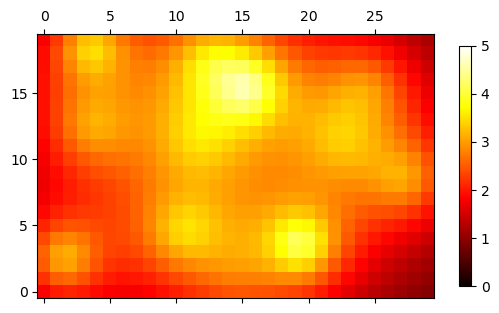

In [8]:
# Laver vektoren der indeholder belysningerne, om til en matrice som matcher parkeringspladsen
belysning = np.ndarray((20, 30))

for i in range(600):
    col = i % 30
    row = i // 30
    belysning[row][col] = y[i]
    
# Plotter skidtet
fig, ax = plt.subplots()
im = ax.matshow(belysning, cmap='hot', clim=(0.0, 5), origin='lower')
fig.colorbar(im, shrink=0.65)

## c) 
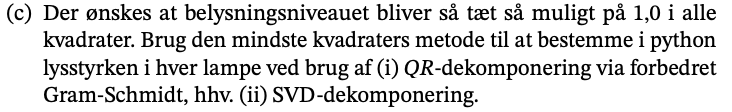

In [9]:
# Først definerer jeg en y-vector med indgange med værdien 1.
ønskety = np.ones((600, 1))

### i) Bestemmelse af lysstyrken i alle lamperne vha Gram-Schmidt

In [10]:
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

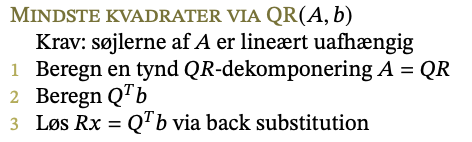

In [11]:
# 1.
# Beregning af QR-dekomponering af A
q, r = forbedret_gram_schmidt(A)


In [12]:
# 2.
# Beregning af Q^Tb
QTb = q.T @ ønskety

In [13]:
# Defination af backsubstitution
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [14]:
# 3.
# Jeg løser ligningen for at bestemme mine lampers lysstyrke. Kommer af formlen 𝑅𝑥 = 𝑄^𝑇 * 𝑏.
xgs = back_subs(r, QTb)

xgs

array([[ 9.62564446],
       [ 9.73479073],
       [ 6.58636602],
       [ 5.57725197],
       [ 4.5904294 ],
       [ 6.45850881],
       [11.10197522],
       [ 3.31142733],
       [ 5.62748205],
       [ 1.81814075],
       [12.71525118],
       [10.87248321]])

In [15]:
# Beregning af lyset på felterne med de beregnede lamper (x-vektoren)
ygs = A @ xgs

C:\Users\Bruger\AppData\Local\Temp\ipykernel_11460\1387623180.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  belysninggs[col][row] = ygs[i]


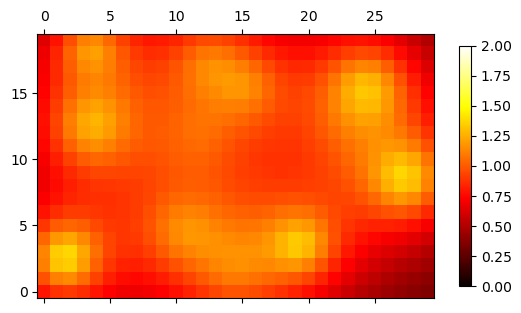

In [16]:
# Laver vektoren der indeholder belysningerne, om til en matrice som matcher parkeringspladsen
belysninggs = np.ndarray((20, 30))

for i in range(600):
    row = i % 30
    col = i // 30
    belysninggs[col][row] = ygs[i]
    
# Plotter skidtet
fig, ax = plt.subplots()
im = ax.matshow(belysninggs, cmap='hot', clim=(0.0, 2), origin='lower')
fig.colorbar(im, shrink=0.65)

### ii) Bestemmelse af lysstyrkerne vha SVD

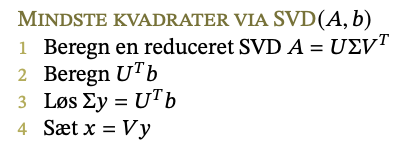

In [17]:
# 1.
# Beregner SVd'en til matricen A
u, sigma, vt = np.linalg.svd(A, full_matrices=False)

In [18]:
# 2.
# Beregning af U^Tb
UTb = u.T @ ønskety

In [19]:
# 3.
# Løsning af ligningen, ved at gange den inverse, til singulærværdierne, til på begge sider.
y = np.linalg.inv(np.diag(sigma)) @ UTb

In [20]:
# 4.
# Beregning af lampernes lysstyrke (x-værdierne)
xsvd = vt.T @ y

xsvd

array([[ 9.62564446],
       [ 9.73479073],
       [ 6.58636602],
       [ 5.57725197],
       [ 4.5904294 ],
       [ 6.45850881],
       [11.10197522],
       [ 3.31142733],
       [ 5.62748205],
       [ 1.81814075],
       [12.71525118],
       [10.87248321]])

In [21]:
# Beregning af lyset på felterne med de beregnede lamper
ysvd = A @ xsvd

C:\Users\Bruger\AppData\Local\Temp\ipykernel_11460\2390864163.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  belysningsvd[col][row] = ysvd[i]


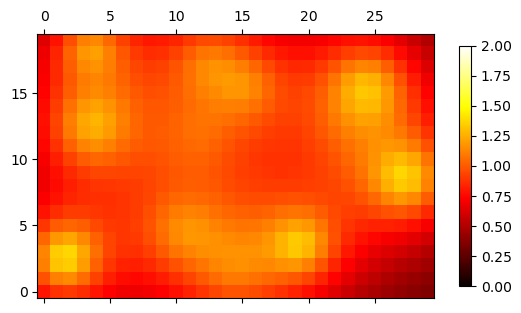

In [22]:
# Laver vektoren der indeholder belysningerne, om til en matrice som matcher parkeringspladsen
belysningsvd = np.ndarray((20, 30))

for i in range(600):
    row = i % 30
    col = i // 30
    belysningsvd[col][row] = ysvd[i]
    
# Plotter skidtet
fig, ax = plt.subplots()
im = ax.matshow(belysningsvd, cmap='hot', clim=(0.0, 2), origin='lower')
fig.colorbar(im, shrink=0.65)

Tjek af om alle lampestyrker er større end 0.

In [40]:
len([i for i in xgs if i >= 0]), len([i for i in xsvd if i >= 0]), max([abs(y - 1) for y in ygs]), max([abs(y - 1) for y in ysvd])

(12, 12, array([0.64466315]), array([0.64466315]))

## d)
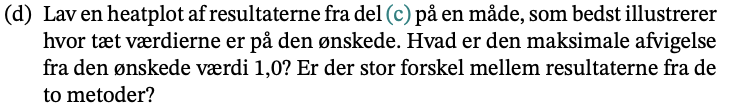

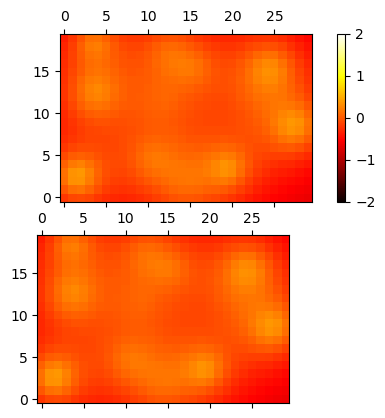

In [24]:
# Plotter skidtet
etlike = np.ones_like(belysninggs)

fig, ax = plt.subplots(2)
imgs = ax[0].matshow(belysninggs - etlike, cmap='hot', clim=(-2.0, 2), origin='lower')
imsvd = ax[1].matshow(belysningsvd - etlike, cmap='hot', clim=(-2.0, 2), origin='lower')
fig.colorbar(imgs)


In [25]:
# Defination af funktion der bestemmer den maksimale afvigelse fra et givet tal:
def maxafvigelse(a, v):
    result = 0
    
    X, Y = a.shape
    for x in range(X):
        for y in range(Y):
            if (result < abs(v - a[x, y])):
                result = abs(v - a[x, y])
    return result
            

In [26]:
# Bestemmelse af maksimal afvigelse for begge metoder:
afvigelsegs = maxafvigelse(belysninggs, 1)
afvigelsesvd = maxafvigelse(belysningsvd, 1)

afvigelsegs, afvigelsesvd

(0.6446631480975298, 0.6446631480975298)

In [27]:
afvigelsegs - afvigelsesvd

0.0

In [28]:
belysninggs - belysningsvd

array([[ 2.22044605e-16,  4.44089210e-16,  3.33066907e-16,
         3.33066907e-16,  2.22044605e-16,  1.11022302e-16,
        -1.11022302e-16, -2.22044605e-16, -4.44089210e-16,
        -7.77156117e-16, -1.33226763e-15, -2.22044605e-15,
        -2.99760217e-15, -4.10782519e-15, -4.66293670e-15,
        -4.77395901e-15, -4.21884749e-15, -3.10862447e-15,
        -1.99840144e-15, -1.11022302e-15, -4.44089210e-16,
        -1.11022302e-16,  0.00000000e+00, -1.11022302e-16,
        -1.11022302e-16,  0.00000000e+00, -5.55111512e-17,
         0.00000000e+00,  5.55111512e-17,  0.00000000e+00],
       [ 6.66133815e-16,  6.66133815e-16,  6.66133815e-16,
         6.66133815e-16,  3.33066907e-16,  1.11022302e-16,
         1.11022302e-16,  1.11022302e-16, -1.11022302e-16,
        -2.22044605e-16, -7.77156117e-16, -1.66533454e-15,
        -2.88657986e-15, -4.21884749e-15, -5.10702591e-15,
        -5.32907052e-15, -4.44089210e-15, -3.10862447e-15,
        -1.55431223e-15, -3.33066907e-16,  3.33066907e-

Der er altså ikke rigtig nogen forskel på de to metoder, og den forskel der er, ligger i nærheden af machine epsilon.

## e)
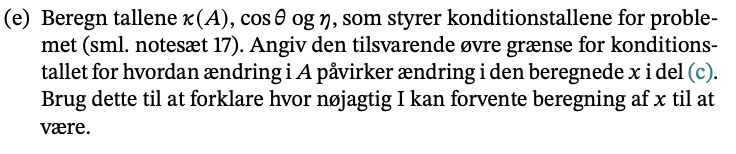

Beregning af $\kappa (A), cos \theta$ og $\eta$ vha metoden fra notesæt 17.

Jeg bruger følgende formler fra notesættet:

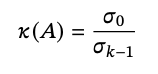

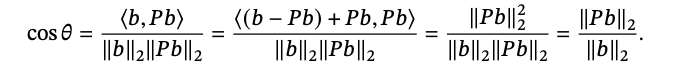

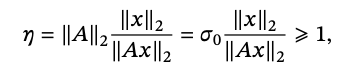

17.3

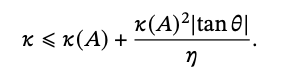


In [29]:
# Beregning af svd for A matricen
u, sigma, vt = np.linalg.svd(A, full_matrices=False)

# Beregning af konditionstallet for A
kappa_a = sigma[0] / sigma[-1]

# Beregning af Pb (projektionen af b på A's søjlerum) fra formlen Ax = Pb
b = ønskety

Pb = (u @ u.T) @ b

# Beregning af cos theta
cos_theta = np.linalg.norm(Pb) / np.linalg.norm(b)

# Angivelse af de bestemte x-værdier (lamperne) for svd.
x = xsvd

# Bestemmelse af eta, her indsættes Pb da den er lig Ax
eta = sigma[0] * np.linalg.norm(x) / np.linalg.norm(Pb)

# Bestemmelse af konditionstallet for hele beregningen af x
kond_x_a_højst = (kappa_a + (kappa_a**2 * abs(np.tan(np.arccos(cos_theta))) / eta))


In [30]:
kappa_a

8.232313043873104

In [31]:
cos_theta

0.9839509931803868

In [32]:
eta

1.1810148986167572

In [33]:
kond_x_a_højst

18.638807553737323

Jeg ved nu at de beregnede værdier, ved begge metoder (SVD og Gram Schmidt), vil ligge indenfor følgende interval, som kan beregnes således:

$$[x_i * (1 - (\epsilon_{machine} * \kappa)),  x_i * (\epsilon_{machine} * \kappa)]$$

Hvor $x_i$ er den korrekte værdi for den i'te lampe, $\epsilon_{machine}$ er den relative fejl som alle floats vil have, og $k(x)$ er det størst mulige konditionstal for beregningen.

Denne fejl kommer af at $\kappa$ er en skalar for hvor mange gange større dn relative fejl bliver når vi udfører beregningen. 



Formlen ovenfor holder selvfølgelig kun hvis man har målt lampernes positioner helt perfekt. Hvis dette ikke er tilfældet, så er man nødt til at beregne den relative fejl for A, og indsætte den, plus $\epsilon_{machine}$.

In [34]:
# Vi kan altså forvente at fejlen ligger indenfor:
kond_x_a_højst * np.finfo(float).eps

4.138646659543293e-15